# iprPy diffusion_liquid calculation

In [1]:
# Standard library imports
import datetime
from copy import deepcopy

# http://www.numpy.org/
import numpy as np

# https://ipython.org/
from IPython.display import display, Code, Markdown, Pretty, Image

import matplotlib.pyplot as plt

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc

# https://github.com/usnistgov/iprPy
import iprPy

print('Notebook last executed on', datetime.date.today(), 'using iprPy version', iprPy.__version__)

Notebook last executed on 2026-07-06 using iprPy version 0.12.a


## 1. Load calculation and view description

### 1.1. Load the calculation

In [2]:
# Load the calculation being demoed
calculation = iprPy.load_calculation('diffusion_liquid')

### 1.2. Display calculation description and theory

In [3]:
# Display main docs and theory
display(Markdown(calculation.maindoc))
display(Markdown(calculation.theorydoc))

# diffusion_liquid calculation style

**Lucas M. Hale**, [lucas.hale@nist.gov](mailto:lucas.hale@nist.gov?Subject=ipr-demo), *Materials Science and Engineering Division, NIST*.

## Introduction

The diffusion_liquid calculation style estimates the diffusion constant of a liquid using both mean squared displacements (MSD) and the velocity auto correlation function (VACF).

### Version notes

- 2025-??: Initial version of the calculation added.
- 2026-: Calculation updated for the new LAMMPS interface.  The short MSD calculation was changed.

### Additional dependencies

### Disclaimers

- [NIST disclaimers](http://www.nist.gov/public_affairs/disclaimer.cfm)
- 

## Simulation design

The diffusion_liquid calculation performs multiple NVT MD simulations at a target temperature, with the only difference between the multiple stages/runs being what properties are computed.  The first optional stage is an equilibrium stage that allows for atomic velocities to equilibrate if the initial configuration is not already equilibrated. Multiple subsequent runs are then performed during which evaluations of the mean squared displacement (MSD) and the velocity auto-correlation function (VACF) are reset at the beginning of each smaller run. Final analysis provides three estimates of the diffusion constant: MSD long being the MSD estimate for the entire simulation time (post equilibration stage), MSD short being the averaged MSD estimates from the individual short runs, and VACF being the averaged VACF estimates from the individual short runs.

## MSD estimates

The MSD of all atoms in the system gives an averaged metric for how far atoms on average diffuse during a given time period. LAMMPS computes this value at every outputted timestep by evaluating $\left<Δr^2\right>$ for $Δr$ values relative to the timestep where the compute was started, and averaged over all atoms in the system. Once MSD is computed as a function of Δt, the diffusion constant can be evaluated using

$$ D = \frac{\left< Δr^2 \right>}{2dΔt},$$ 

where d is the number of dimensions included. Using this equation, D is typically estimated through a linear fit to compute the slope between the MSD and Δt.  When computing the linear fit, the beginning of the MSD curve is excluded (default is 400 timesteps) as the arbitrary reference configuration can skew the initial MSD values.

### Long MSD vs. short MSD

This calculation provides two estimates of the diffusion constant based on MSD values: long MSD and short MSD.  For long MSD, $\left<Δr^2\right>$ is computed across the full cumulative simulation time. For short MSD, $\left<Δr^2\right>$ is computed for each short simulation time, then a mean curve is obtained by averaging MSD values for the same Δt across all short runs.  This effectively allows for the $\left<Δr^2\right>$ values to be averaged over more samples thereby likely providing a better more consistent MSD vs Δt curve.

### VACF

The LAMMPS compute vacf method evaluates the VACF at every outputted timestep by evaluating $\left<v_0 ⋅ v_t\right>$ averaged over all atoms using $v_0$ values obtained at the timestep when the compute was started. Estimates for the diffusion constant can be obtained by integrating the VACF as a function of time.

$$ D = \frac{1}{d}\int_0^\infty{\left<v_0 ⋅ v_t\right>dt}, $$

where d is the number of dimensions included.

For the integral to converge to a finite value, the VACF is expected to quickly drop to 0.0. However, when you run simulations the VACF is typically found to fluctuate around a constant value (close to but not always zero) at large Δt. This can be reduced by increasing the number of samples being averaged, i.e. increasing the number of atoms and/or adding additional VACF measurements for the same Δt values.  This calculation does the second option by resetting the VACF calculation at the beginning of each short simulation run. 
 

## 2. Display the underlying code

This section displays the underlying code used when calculation.calc() is called in Section 4. It is provided here allowing any users to see and understand how the calculation works.

Feel free to modify and test the functions for yourself!  You can do this by
1. Copy the Python code displayed here into a "Code" cell and run it.
2. In Section 2.2, set "savefiles = True" and run the cell to save any supporting non-python files to the working directory.
3. In Section 4, call the primary calculation function directly rather than using calculation.calc().

### 2.1. Show code and supporting file names and content

In [4]:
# Display calculation code and supporting files
for filename, contents in calculation.files.items():
    display(Markdown(f'## Contents of file "{filename}"'))
    if filename[-3:] == '.py':
        display(Code(contents, language='python'))
    else:
        display(Pretty(contents))

## Contents of file "diffusion_liquid.py"

# Python script created by Peter Winstel and Lucas Hale

# Standard library imports
from typing import Optional, Union

# http://www.numpy.org/
import numpy as np

from scipy.integrate import trapezoid
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc
from atomman.typing import lammpspotential, unitfloat
from atomman.lammps import LAMMPS, LAMMPSobj


def diffusion_liquid(lammps_command: Union[str, LAMMPSobj],
                     system: am.System,
                     potential: lammpspotential,
                     temperature: float,
                     mpi_command: Optional[str] = None,
                     timestep: Optional[unitfloat] = None,
                     equilsteps: int = 0,
                     runsteps: int = 2000,
                     simruns: int = 100,
                     msd_start: int = 500,
                     createvelocities: bool = False,
                     randomseed: Optional[int] = None,
                     usefiles: bool = False) -> dict:
    """
    Calculates the diffusion constant for a liquid system using both
    mean squared displacements and the velocity auto-correlation function.

    Parameters
    ----------
    lammps_command : str, LAMMPSEXE or LAMMPSLIB
        LAMMPS executable command, LAMMPS library name, or an atomman LAMMPS
        interface object.
    system : atomman.System
        The system to perform the calculation on.
    potential : atomman.lammps.Potential
        the LAMMPS implemented potential to use.
    temperature : float
        The temperature to run at.
    mpi_command : str, optional
        The MPI command for running LAMMPS in parallel. If not given, LAMMPS
        will run serially.
    timestep : float, str or None, optional
        The amount of time to increase each frame of the simulation. The 
        default value is given by the default value for the specified LAMMPS
        unit system.
    equilsteps : int, optional
        How many timesteps to run to equilibrate the system before starting the
        diffusion calculations. Default value is 0.
    runsteps : int, optional
        How many timesteps each short diffusion simulation will run for.  This
        should be a good value for the velocity auto correlation function,
        typically in the low 1000's.  Default value is 2000.
    simruns : int, optional
        The number of short diffusion simulations to run. The VACF and short
        MSD values are averaged over the runs.  Default value of 100.
    msd_start : int, optional
        The starting timestep for including MSD data in the MSD diffusion
        calculations.  Initial values should be ignored due to correlation
        with the initial atomic positions for the MSD run.  Default value is
        500.
    createvelocities : bool, optional
        If True, velocities will be created for the atoms prior to running the
        simulations.  Default value is False, which assumes the initial system
        already has velocity information.  Typically, if this is True then
        equilsteps > 0.
    randomseed : int or None, optional
        Random number seed used by LAMMPS in creating velocities and with
        the Langevin thermostat.  Default is None which will select a
        random int between 1 and 900000000.
    usefiles : bool, optional
        If set to True, then all input/output files for LAMMPS will be generated.
        Default value of False will minimize the files created.
    
    Returns
    -------
    dict
        Dictionary of results consisting of keys:

        -**'diffusion_msd_short'** (*float*) - The diffusion constant estimate
        obtained using the slope of the mean squared displacement averaged over
        all separate simulations.
        -**'diffusion_msd_long'** (*float*) - The diffusion constant estimate
        obtained from the mean squared displacement slope of the full comb

### 2.2. Optional: Save supporting files

Set "savefiles = True" to save files locally.  

Note that the code above should be using atomman.tools.read_calc_file() to read the files, which will read any local files with matching names if they exist or read the packaged version if the local files do not exist. This means that if you save the files locally, you can modify them and see how it affects the calculation!

In [5]:
savefiles = False

if savefiles:
    for filename, contents in calculation.files.items():
        if filename[-3:] != '.py':
            with open(filename, 'w') as f:
                f.write(contents)

## 3. Specify input parameters

### 3.1. System-specific paths

- __lammps_command__ is the LAMMPS command to use (required).
- __mpi_command__ MPI command for running LAMMPS in parallel. A value of None will run simulations serially.

In [6]:
lammps_command = 'lmp_serial'
mpi_command = None
#mpi_command = 'mpiexec -localonly 6'

# Optional: check that LAMMPS works and show its version 
print(f'LAMMPS version = {am.lammps.checkversion(lammps_command)["version"]}')

LAMMPS version = 3 Mar 2020


### 3.2. Interatomic potential

- __potential_name__ gives the name of a potential_LAMMPS record to find and download from the iprPy library.  
- __potential__ is a potential_LAMMPS or potential_LAMMPS_KIM record object (required).

See documentation for the [potentials package](https://github.com/usnistgov/potentials/tree/master/doc) for more options on finding, loading and building potential objects (doc Notebook #s 0, 5.3, 5.4 and 7).

In [7]:
potential_name = '1999--Mishin-Y--Ni--LAMMPS--ipr1'

# Retrieve potential and parameter file(s) using atomman
potential = am.load_lammps_potential(id=potential_name, getfiles=True)

### 3.3. Initial system

- __system__ is an atomman.System to use as the starting configuration.  Here, it is taken as the final configuration from the relax_liquid calculation.

See documentation for the [atomman package](https://github.com/lmhale99/atomman/tree/master/doc/tutorial) for more options on building and loading atomic configurations (doc Notebook #s 1.1, 1.2, 1.3, 1.4 and 1.4.*)

In [8]:
# Load final configuration from relax_liquid
system = am.load('atom_dump', '../relax_liquid/100000.dump', symbols='Ni')
print('# of atoms in system =', system.natoms)

# of atoms in system = 4000


### 3.4. Calculation-specific parameters

- __temperature__ is the temperature to run the calculation at.
- __timestep__ is the integration timestep to use. If None, then will use the default timestep for the LAMMPS units associated with the potential.
- __equilsteps__ is the number of integration steps to perform both before starting the diffusion calculations.  
- __runsteps__ is the number of integration steps to perform for each short simulation used to evaluate the VACF and short MSD.  Default value is 2000.  Note that the total simulation time will be runsteps * simruns.
- __simruns__ is the number of short MSD simulations to run.  Default value is 100.  Note that the total simulation time will be runsteps * simruns.
- __msd_start__ is the starting timestep for including MSD data in the MSD diffusion calculations.  Initial values should be ignored due to correlation with the initial atomic positions for the MSD run.  Default value is 500.
- __createvelocities__ indicates if new atomic velocities are to be assigned to the atoms prior to any MD runs.
- __randomseed__ is a random number seed between 1 and 9000000 to use for initializing velocities and use with the langevin thermostat.  Default value of None will pick a random value.

In [9]:
temperature = 2000.0
timestep = None
equilsteps = 0
runsteps = 2000
simruns = 100
msd_start = 500
createvelocities = False
randomseed = None

## 4. Run calculation and view results

### 4.1. Run calculation

All primary calculation method functions take a series of inputs and return a dictionary of outputs.

In [10]:
# What is calculation.calc an alias of?
calculation.calc.__module__

'iprPy.calculation.diffusion_liquid.diffusion_liquid'

In [11]:
results_dict = calculation.calc(lammps_command, system, potential, temperature,
                                mpi_command = mpi_command,
                                timestep = timestep,
                                equilsteps = equilsteps,
                                runsteps = runsteps,
                                simruns = simruns,
                                msd_start = msd_start,
                                createvelocities = createvelocities,
                                randomseed = randomseed,
                                usefiles=True)
print(results_dict.keys())

dict_keys(['diffusion_msd_short', 'diffusion_msd_long', 'diffusion_vacf', 'measured_temperature', 'lammps_output'])


### 4.2. Report results

Values returned in the results_dict:

- **'diffusion_msd_short'** (*float*) - The diffusion constant estimate obtained using the slope of the mean squared displacement averaged over all separate simulations.
- **'diffusion_msd_long'** (*float*) - The diffusion constant estimate obtained from the mean squared displacement slope of the full combined simulation run.
- **'diffusion_vacf'** (*float*) - The diffusion constant estimate obtained using the velocity auto correlation function averaged over all separate simulations.
- **'measured_temperature'** (*float*) - The mean observed temperature.
- **'lammps_output'** (*atomman.lammps.Log*) - The LAMMPS thermo output, included to allow for further analysis.

In [12]:
diffusion_unit = 'm^2/s'
print('D_msd_long  =', uc.get_in_units(results_dict['diffusion_msd_long'], diffusion_unit), diffusion_unit)
print('D_msd_short =', uc.get_in_units(results_dict['diffusion_msd_short'], diffusion_unit), diffusion_unit)
print('D_vacf      =', uc.get_in_units(results_dict['diffusion_vacf'], diffusion_unit), diffusion_unit)

D_msd_long  = 2.6406674917690282e-09 m^2/s
D_msd_short = 2.6138833956293538e-09 m^2/s
D_vacf      = 2.6233689061757378e-09 m^2/s


Additionally, the calculation automatically generates plots for validation purposes

- __MSD Long.png__ plots MSD vs $\Delta t$ obtained for the full combined simulation run.  If the line appears straight, then the associated diffusion estimate is likely good.
- __MSD Short.png__ plots MSD vs $\Delta t$ obtained for each short simulation run, as well as the averaged values shown with a heavy black line.  The individual runs should show some scatter, but the mean line should be straight to give a good associated diffusion estimate.
- __VACF.png__ plots VACF vs $\Delta t$ obtained for each short simulation run, as well as the averaged values shown with a heavy black line. The individual runs should show some scatter, but the mean line should drop to 0.0 and remain there with little fluctuation.


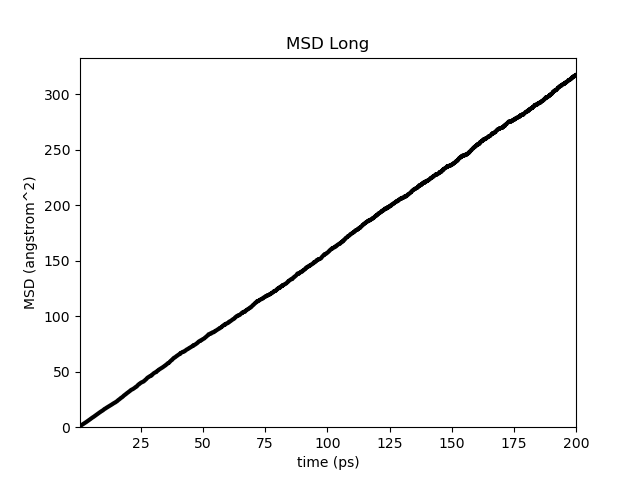

In [13]:
Image('MSD Long.png')

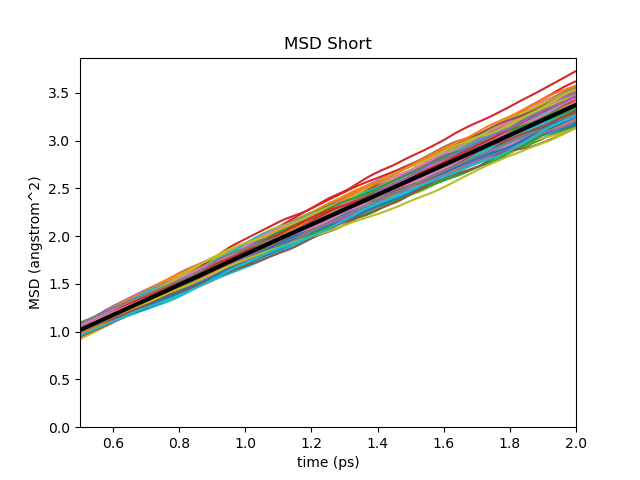

In [14]:
Image('MSD Short.png')

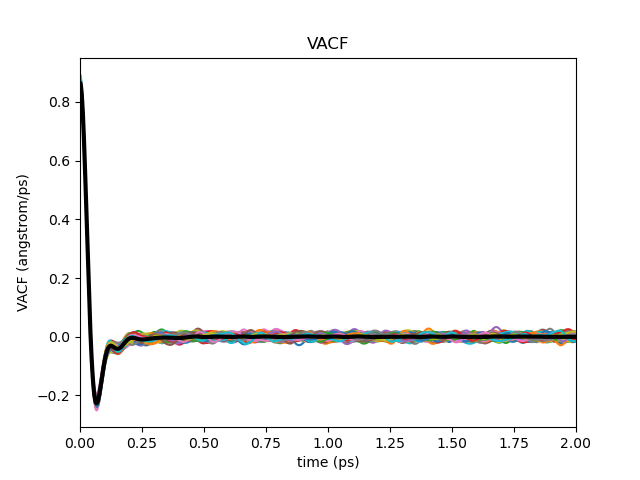

In [15]:
Image('VACF.png')

In [16]:
log = am.lammps.Log('log.lammps')

In [19]:
log.simulations[1].thermo

,Step,Temp,c_vacf[1],c_vacf[2],c_vacf[3],c_vacf[4],c_msdShort[1],c_msdShort[2],c_msdShort[3],c_msdShort[4],c_msdLong[1],c_msdLong[2],c_msdLong[3],c_msdLong[4]
0,0,2023.456541,28.840032,29.004012,28.102649,85.946693,1.262177e-30,1.287421e-30,7.738725e-31,3.323471e-30,1.262177e-30,1.287421e-30,7.738725e-31,3.323471e-30
1,1,2025.760047,28.835497,29.010237,28.068397,85.914131,2.887716e-05,2.904972e-05,2.810848e-05,8.603536e-05,2.887716e-05,2.904972e-05,2.810848e-05,8.603536e-05
2,2,2028.143172,28.775436,28.964110,27.981465,85.721011,1.155453e-04,1.162778e-04,1.123549e-04,3.441780e-04,1.155453e-04,1.162778e-04,1.123549e-04,3.441780e-04
3,3,2030.577085,28.660174,28.865815,27.842291,85.368280,2.599746e-04,2.617244e-04,2.525494e-04,7.742485e-04,2.599746e-04,2.617244e-04,2.525494e-04,7.742485e-04
4,4,2033.035663,28.490251,28.715746,27.651561,84.857557,4.620235e-04,4.653226e-04,4.484072e-04,1.375753e-03,4.620235e-04,4.653226e-04,4.484072e-04,1.375753e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,1996,1991.933290,-0.496418,-0.209585,-0.115580,-0.821583,9.934683e-01,1.064266e+00,1.112373e+00,3.170107e+00,9.934683e-01,1.064266e+00,1.112373e+00,3.170107e+00
1997,1997,1992.849251,-0.481558,-0.222743,-0.103915,-0.808216,9.939622e-01,1.064681e+00,1.112634e+00,3.171278e+00,9.939622e-01,1.064681e+00,1.112634e+00,3.171278e+00
1998,1998,1993.671155,-0.465412,-0.235607,-0.092520,-0.793539,9.944537e-01,1.065100e+00,1.112890e+00,3.172444e+00,9.944537e-01,1.065100e+00,1.112890e+00,3.172444e+00
1999,1999,1994.396367,-0.448084,-0.248163,-0.081548,-0.777795,9.949428e-01,1.065522e+00,1.113143e+00,3.173607e+00,9.949428e-01,1.065522e+00,1.113143e+00,3.173607e+00


In [43]:
time = log.simulations[1].thermo.Step * uc.set_in_units(0.001, 'ps')
vacf_x = uc.set_in_units(log.simulations[1].thermo['c_vacf[1]'], '(angstrom/ps)^2')

In [33]:
vacf_x = np.zeros_like(time)
for i in range(1, len(log.simulations)):
    vacf_x += uc.set_in_units(log.simulations[i].thermo['c_vacf[1]'], '(angstrom/ps)^2')
vacf_x = vacf_x / (len(log.simulations)-1)

In [44]:
gk = am.thermo.GreenKubo(time, acf=vacf_x, fluctuation_delta=5)

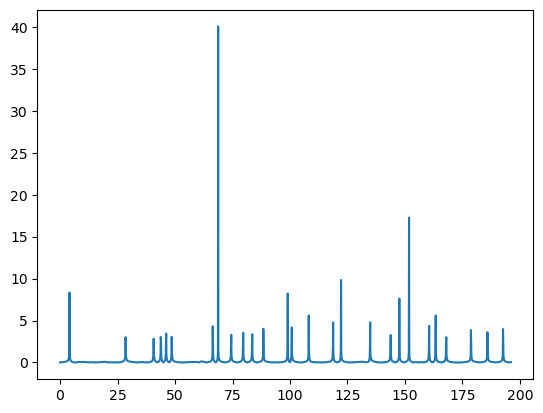

In [45]:
plt.plot(gk.time[:-4], gk.fluctuation)

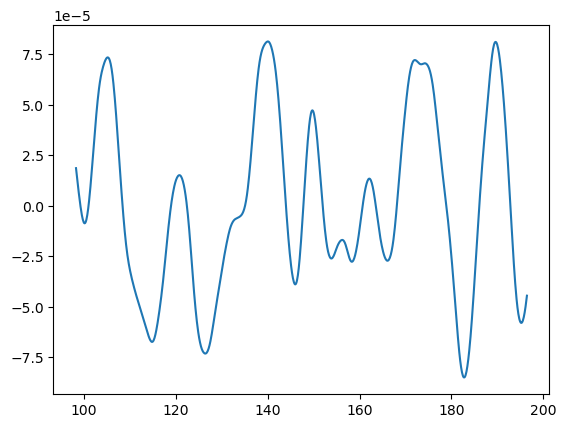

In [65]:
plt.plot(gk.time[1000:], gk.acf[1000:])

In [67]:
sigma = np.var(gk.acf[1000:])

(0.0, 100.0)

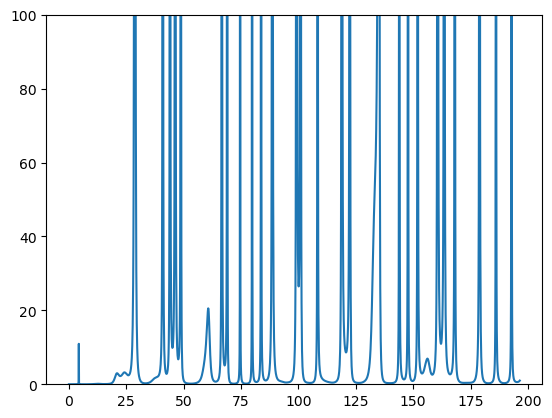

In [73]:
plt.plot(gk.time, (sigma / gk.acf**2))
plt.ylim(0, 100)

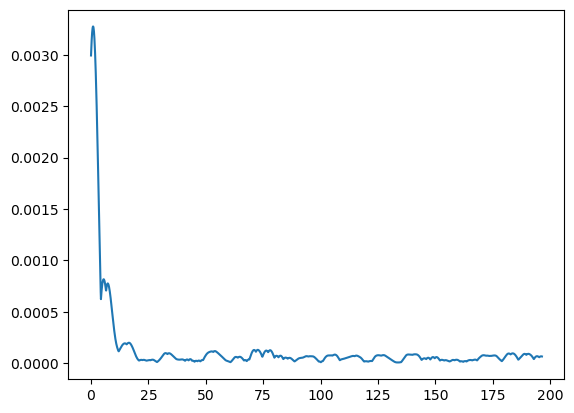

In [61]:
plt.plot(gk.time[:-1], np.abs(gk.acf)[:-1] + np.abs(np.diff(gk.acf, n=1))*10)


In [ ]:
np.diff(gk.acf)

(0.0, 1e-06)

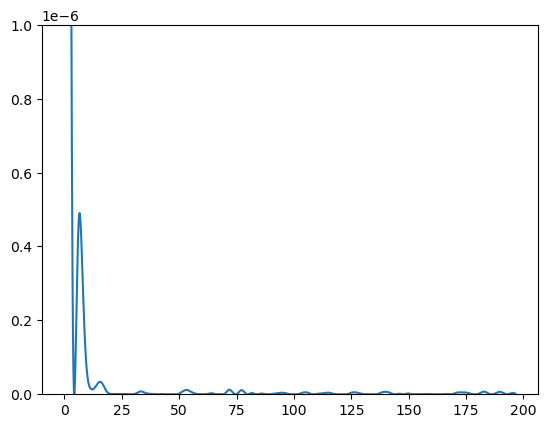

In [63]:
plt.plot(gk.time, gk.acf**2 + )
plt.ylim(0, 1e-6)

### 4.3. Optional: Clean calculation files

The calculation may generate output files when it runs.  Calling calculation.clean_files() will delete any generated files to keep the workspace clean.

In [16]:
calculation.clean_files()